# Q3: How do the reports of the category VBZ/ÖV cluster over the city?
One category of the Züri wie neu reports are related to public transport. By visualising the reports of this category, I want to see whether "public transport problems" hotspots can be identified.

Summarized workflow:

0. Import the packages 
1. Import all datasets needed for preparing the data for visualisation
2. Filter all reports of the category VBZ/ÖV
3. Import the cartographic elements (map and public transport lines) 
4. Visualise the spatial distribution of the reports

## 0. Import section

In [7]:
import geopandas as gpd
import matplotlib.pyplot as plt

import sys
sys.path.append("../scripts") #to load the .py script

from functions_zh_wie_neu import import_preprocessed_data #type: ignore
from functions_zh_wie_neu import export_result_to_png #type: ignore

# 1. Import the dataset of the spatially joined report
All the attributes needed are found within one file. Therefore, only the *reports_quartiere_sjoin.gpkg* file is imported.

In [8]:
reports_full=import_preprocessed_data("reports_quartiere_sjoin.gpkg")

#sanity check
reports_full.head(2)

The active geometry column of this geodataframe is called 'geometry'.


,service_request_id,requested_datetime,e,n,service_code,description,index_right,qnr,qname,knr,kname,geometry
0,1,2013-03-14 15:16:15,2678968,1247548,Strasse/Trottoir/Platz,Auf dem Asp: Auf dem Asphalt des Bürgersteigs ...,16,91,Albisrieden,9,Kreis 9,POINT (2678968 1247548)
1,2,2013-03-14 15:17:57,2680746,1249916,Strasse/Trottoir/Platz,Vermessungs: Vermessungspunkt ist nicht mehr b...,20,101,Höngg,10,Kreis 10,POINT (2680746 1249916)


## 2. Filter for the category VBZ/ÖV 
In this step, I want to filter the reports to create a new subset called reports_public_transport, containing all reports of the VBZ/ÖV category.

In [9]:
reports_public_transport=reports_full[reports_full["service_code"]=="VBZ/ÖV"]

print(reports_public_transport.shape) #roughly 1900 reports relating public transport

(1898, 12)


## 3. Import the data needed for the visualisations
For the subsequent visualisations, I would like to use the _map layer of the quartiere dataset, as it is recommended for data visualisations. Further, the public transport lines are imported as well. They serve to better emphasize the location of the reports along the public transport network.

In [10]:
quartiere_map=import_preprocessed_data("quartiere_map.gpkg") #background map: neighborhood polygons
railway_lines=import_preprocessed_data("railway_lines.gpkg") #railway lines
vbz_lines=import_preprocessed_data("vbz_lines.gpkg") #Tram and Bus lines

The active geometry column of this geodataframe is called 'geometry'.
The active geometry column of this geodataframe is called 'geometry'.
The active geometry column of this geodataframe is called 'geometry'.


## 4. Plot the spatial distribution of public transport related reports
As a visual map showing the locations of all public transport related reports in Zurich is created. The idea is to use the quartiere_map polygons as the background. Then, the report locations are plotted on top. To be able to better emphasize the locations of the reports, the railway, bus and tram lines are plotted as well.

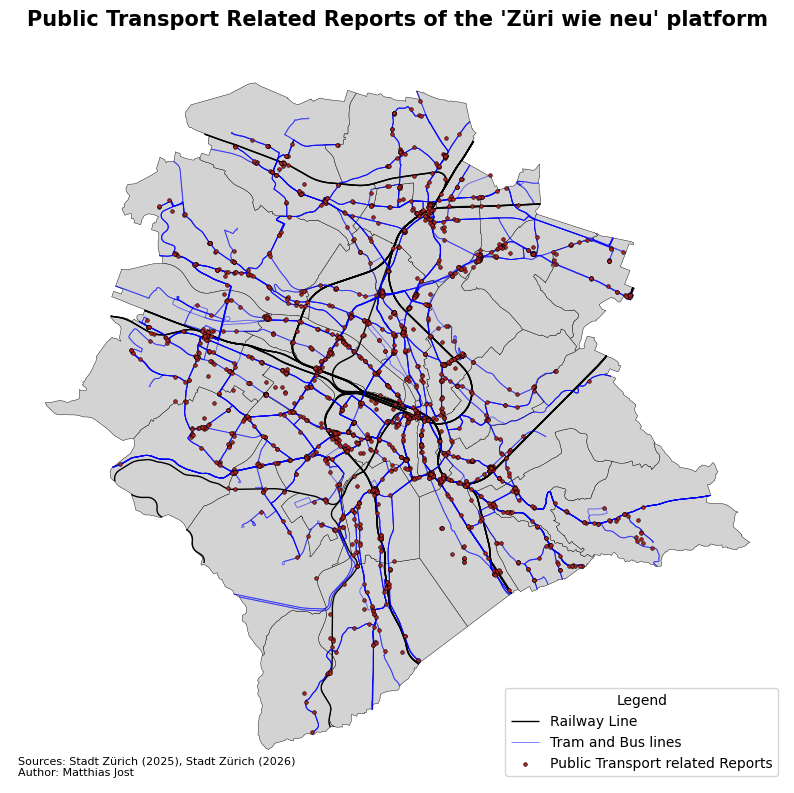

In [11]:
fig, ax=plt.subplots(figsize=(10,10))

#plot the layers
quartiere_map.plot(ax=ax, color="lightgrey", edgecolor="black", linewidth=0.3, zorder=0)
railway_lines.plot(ax=ax, color="black", linewidth=1, zorder=1, label="Railway Line")
vbz_lines.plot(ax=ax, color="blue", linewidth=0.7, zorder=2, label="Tram and Bus lines", alpha=0.5)
reports_public_transport.plot(ax=ax, color="firebrick", markersize=7, edgecolor="black", linewidth=0.4, zorder=3, label="Public Transport related Reports")

#set all further aesthetics
ax.axis("off")
ax.set_title("Public Transport Related Reports of the 'Züri wie neu' platform", fontsize=15, fontweight="bold")
ax.legend(title="Legend", loc="lower right")
ax.text(0.01,0.01, "Sources: Stadt Zürich (2025), Stadt Zürich (2026) \nAuthor: Matthias Jost", transform=ax.transAxes, fontsize=8)

#export the resulting map
export_result_to_png("Q3_public_transport_related_reports_map")
plt.show()

The Züri Wie Neu reports related to public transport problems predominantly appear along major public transport lines. The biggest clusters are found at nodes of the network, such as Zurich Main Station, Oerlikon, Altstetten and Wiedikon. Another big cluster appears slightly north of the campus Irchel. It appear to coincides with the underground section of the tramway to Stettbach. Last but not least, it is noteworthy that the entire length of the Rigiblick cablecare is covered with reports.